In [1]:
import sys
sys.path.insert(0, "..")

import os
print(os.getcwd())

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

%load_ext autoreload
%autoreload 2

c:\Users\gdev\Documents\CS\DL\projects\Robotics\vjepa2\notebooks


In [56]:
import torch
import numpy as np

from torch.nn import functional as F
from PIL import Image

import matplotlib.pyplot as plt

[INFO    ][2026-09-08 15:29:07][matplotlib.font_manager][_load_fontmanager        ] generated new fontManager


In [3]:
# Initialize VJEPA 2-AC model
encoder, predictor = torch.hub.load("facebookresearch/vjepa2", "vjepa2_ac_vit_giant")

Using cache found in C:\Users\gdev/.cache\torch\hub\facebookresearch_vjepa2_main
a:\code\conda_envs\vjepa\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [4]:
from vjepa2.app.vjepa_droid.transforms import make_transforms

from utils.mpc_utils import compute_new_pose

# Initialize transform
crop_size = 256
tokens_per_frame = int((crop_size // encoder.patch_size) ** 2)
print(tokens_per_frame)

transform = make_transforms(
    random_horizontal_flip=False,
    random_resize_aspect_ratio=(1., 1.),
    random_resize_scale=(1., 1.),
    reprob=0.,
    auto_augment=False,
    motion_shift=False,
    crop_size=crop_size,
)

def forward_target(encoder, c, normalize_reps=True):
    #not sure what other stuff is doing but repeat is for the tubelet size of 2

    B, C, T, H, W = c.size()
    c = c.permute(0, 2, 1, 3, 4).flatten(0, 1).unsqueeze(2).repeat(1, 1, 2, 1, 1)
    h = encoder(c)
    h = h.view(B, T, -1, h.size(-1)).flatten(1, 2)
    if normalize_reps:
        h = F.layer_norm(h, (h.size(-1),))
    return h

256


In [ ]:
from utils.world_model_wrapper import WorldModel

#increase cem_steps and samples for more accurate optimization of energy landscape
MPC_ARGS = {
            "rollout": 1,
            "maxnorm": 0.075,
            "max_gd_steps": 10,
            "lr": 0.01
        }

world_model = WorldModel(
        encoder=encoder,
        predictor=predictor,
        tokens_per_frame=tokens_per_frame,
        transform=transform,
        mpc_args= MPC_ARGS,
        normalize_reps=True,
        device="cuda:0"
    )

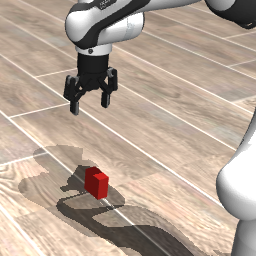

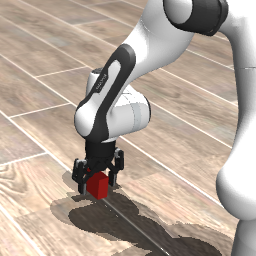

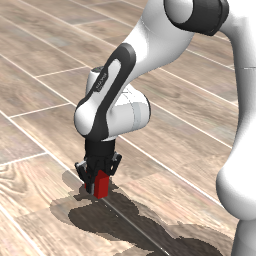

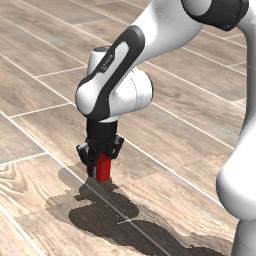

In [48]:
traj_start = np.load("../../custom_gym_env/outputs/capture_1788894462.7028484.npz")
traj_open = np.load("../../custom_gym_env/outputs/capture_1769832812.9509695.npz")
traj_grasp = np.load("../../custom_gym_env/outputs/capture_1769832817.8187528.npz")
traj_lift = np.load("../../custom_gym_env/outputs/capture_1769832838.6913404.npz")

img_start = np.array(Image.fromarray(traj_start['img']).crop((320, 140, 576, 396)))
img_open = np.array(Image.fromarray(traj_open['img']).crop((320, 140, 576, 396)))
img_grasp = np.array(Image.fromarray(traj_grasp['img']).crop((320, 140, 576, 396)))
img_lift = np.array(Image.fromarray(traj_lift['img']).crop((320, 140, 576, 396)))

Image.fromarray(traj_start['img']).crop((320, 140, 576, 396))
Image.fromarray(traj_open['img']).crop((320, 140, 576, 396))
Image.fromarray(traj_grasp['img']).crop((320, 140, 576, 396))
Image.fromarray(traj_lift['img']).crop((320, 140, 576, 396))

In [49]:
state_start = traj_start['state'].copy()
state_start[3:6] = np.radians(state_start[3:6])

state_open = traj_open['state'].copy()
state_open[3:6] = np.radians(state_open[3:6])
traj_open['state']
state_open

state_grasp = traj_grasp['state'].copy()
state_grasp[3:6] = np.radians(state_grasp[3:6])

state_lift = traj_lift['state'].copy()
state_lift[3:6] = np.radians(state_lift[3:6])

array([ 5.00756073e-01, -2.97759982e-03,  1.62745009e-01,  1.79998833e+02,
        8.22132696e-01,  1.65311710e-03,  0.00000000e+00])

array([ 5.00756073e-01, -2.97759982e-03,  1.62745009e-01,  3.14157228e+00,
        1.43489224e-02,  2.88523364e-05,  0.00000000e+00])

In [8]:
z_n.shape

NameError: name 'z_n' is not defined

In [54]:
#a minimlal example of inputting your own actions (batch)
#parts taken from forward_actions (grid version) from energy_landscape_example
def forward_actions(z, a, s):
    #a: [B, T, 7]
    #repeat z,s B times
    def step_predictor(_z, _a, _s):
        normalize_reps=True
        _z = predictor(_z, _a, _s)[:, -tokens_per_frame:]
        if normalize_reps:
            _z = F.layer_norm(_z, (_z.size(-1),))
        _s = compute_new_pose(_s[:, -1:], _a[:, -1:])
        return _z, _s

    z_batch = z[:, :tokens_per_frame].repeat(a.shape[0], 1, 1)
    s_batch = s.repeat(a.shape[0], 1, 1)

    _z, _s = step_predictor(z_batch, a, s_batch)
    return _z, _s

#rep loss
def loss_fn(z, h):
    z, h = z[:, -tokens_per_frame:], h[:, -tokens_per_frame:]
    loss = torch.abs(z - h)  # [B, N, D]
    loss = torch.mean(loss, dim=[1, 2])
    return loss.tolist()

In [78]:
#a1 = torch.stack([torch.tensor([-0.05,0,i,0,0,0,0]) for i in np.arange(-0.1,0.1,0.01)]).unsqueeze(1).float() #.to('cuda:0')
a1 = torch.stack([torch.tensor([0,0,i,0,0,0,0]) for i in np.arange(-1,1.1,0.1)]).unsqueeze(1).float() #.to('cuda:0')

s_n = torch.tensor(np.expand_dims(state_open, (0,1))).float() #.to('cuda:0') #state_start
print(s_n.shape)

with torch.no_grad():
    clips = transform(np.stack([img_open, img_grasp])).unsqueeze(0) #.to('cuda:0') #img_start
    h = forward_target(encoder, clips) #.to('cuda:0')
    #z_hat, s_hat = forward_actions(h, a1, s_n) #h contains both context and goal but only use context
    #loss = loss_fn(z_hat, h)  #rep loss, compare predicted goal to goal

    z_n, z_goal = h[:, :tokens_per_frame], h[:, -tokens_per_frame:]
    print(f"Starting planning...")

actions = world_model.infer_next_action(z_n, s_n, z_goal, method='gd').cpu().numpy()

torch.Size([1, 1, 7])


a:\code\conda_envs\vjepa\Lib\contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


Starting planning...
Ground truth loss: 0.3397082984447479
iter 0: 0.33980607986450195
iter 1: 0.3568475842475891
iter 2: 0.3433167636394501
iter 3: 0.34200596809387207
iter 4: 0.3470177948474884
iter 5: 0.3430612087249756
iter 6: 0.33957111835479736
iter 7: 0.34112101793289185
iter 8: 0.34331849217414856
iter 9: 0.34258079528808594
Best action: tensor([[[ 0.0018, -0.0006,  0.0028,  0.0000,  0.0000,  0.0000,  0.0499]]]) with a loss of 0.33957111835479736


np.float64(-1.0)

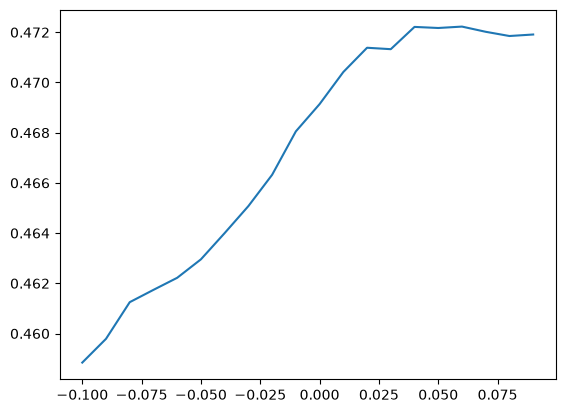

In [76]:
fig, ax = plt.subplots()
np.arange(-1,1.1,0.1)[np.array(loss).argmin()]
ax.plot(np.arange(-0.1,0.1,0.01), loss)

In [73]:
state_grasp[:3] - state_start[:3]

np.linalg.norm(state_start[:3] + actions[0,:3] - state_grasp[:3], 2)
np.linalg.norm(state_start[:3] + np.concat([np.zeros(2), actions[0,2:3]]) - state_grasp[:3], 2)

array([-0.05032053, -0.00296346, -0.20510501])

np.float64(0.15030682054439004)

np.float64(0.14946310272553773)

In [44]:
actions

array([[0.00294988, 0.00056153, 0.00115315, 0.        , 0.        ,
        0.        , 0.00791524]], dtype=float32)